In [4]:
from umap import UMAP
from sklearn.manifold import TSNE, MDS

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from zadu.measures import (
    class_aware_trustworthiness_continuity,
    label_trustworthiness_and_continuity
)

In [5]:
dist_mat = np.load('dist_mat.npy')
labels = np.load('ship-types.npy')
original_data = np.load('original_data.npy')

In [6]:
original_data.shape

(750, 25, 10)

## MDS tyrimas

## t-SNE tyrimas

In [7]:
def plot_tsne(data, perplexity=0.1, early_exaggeration=100, ax=None):
    embeddings = TSNE(perplexity=perplexity, early_exaggeration=early_exaggeration)\
        .fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    print(embeddings[:, 0].shape, embeddings[:, 1].shape)
    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], ax=ax, hue=labels) #, s=25, alpha=0.8, hue=labels, palette='bright', ax=ax)

In [8]:
from itertools import product

In [62]:
default_tsne_hyperparams = {
    "perplexity":         [5, 50, 200],
    "max_iter":             [250, 500, 2000],
    "early_exaggeration": [4.0, 12.0, 24.0],
    "learning_rate":      [10, 100, 1000],
}

keys = list(default_tsne_hyperparams.keys())
values = list(default_tsne_hyperparams.values())

In [63]:
results = []

for combo in product(*values):
    params = dict(zip(keys, combo))

    embedding = TSNE(
        perplexity         = params["perplexity"],
        max_iter           = params["max_iter"],
        early_exaggeration = params["early_exaggeration"],
        learning_rate      = params["learning_rate"],
        metric             = "precomputed",
        init               = "random",
        random_state       = 42,
    ).fit_transform(dist_mat)

    original_flat = original_data.reshape(len(original_data), -1)
    
    trust_score = 0
    cont_score = 0

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity\
            .measure(original_flat, embedding, label=labels, k=k)

        trust_score += ca_tc['ca_trustworthiness'] / 25
        cont_score += ca_tc['ca_continuity'] / 25

    results.append({
        **params,
        "ca_trustworhiness": trust_score,
        'ca_continuity': cont_score,
        "embedding": embedding
    })

In [70]:
results

[{'perplexity': 5,
  'max_iter': 250,
  'early_exaggeration': 4.0,
  'learning_rate': 10,
  'ca_trustworhiness': np.float64(0.9678994004189178),
  'ca_continuity': np.float64(0.952022246730135),
  'embedding': array([[ 1.4347069 ,  2.4692461 ],
         [ 3.3766928 , -0.9419501 ],
         [-6.200645  ,  2.8553104 ],
         ...,
         [-2.602678  ,  7.1135716 ],
         [ 3.1484766 , -0.14034554],
         [ 2.9560022 ,  8.463744  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 5,
  'max_iter': 250,
  'early_exaggeration': 4.0,
  'learning_rate': 100,
  'ca_trustworhiness': np.float64(0.9634587671540484),
  'ca_continuity': np.float64(0.9481654042073836),
  'embedding': array([[ 3.099292 ,  2.4404035],
         [ 3.7692559, -2.1242185],
         [-7.8054676,  2.544828 ],
         ...,
         [-3.9394138,  6.854311 ],
         [ 3.5591347, -1.221009 ],
         [ 2.2295563,  9.56897  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 5,
  'max_iter': 250,
  'early_exagger

In [71]:
def plot_tsne_param(param_name, param_values, distance_matrix, labels=None, random_state=42):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, val in enumerate(param_values):
        params = {param_name: val}

        max_iter = 1000 if param_name != 'max_iter' else val
        perplexity = 50 if param_name != 'perplexity' else val

        if param_name in ['max_iter', 'perplexity']:
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                max_iter=max_iter,
                perplexity=perplexity,
                init="random",
            )

        elif param_name == 'max_iter':
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                perplexity=perplexity,
                init="random",
                **params
            )

        elif param_name == 'perplexity':
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                max_iter=max_iter,
                init="random",
                **params
            )

        else:
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                init="random",
                **params
            )

        embedding = tsne.fit_transform(distance_matrix)

        ax = axes[i]
        original_flat = original_data.reshape(len(original_data), -1)
        
        trust_score = 0
        cont_score = 0

        for k in range(5, 30):
            ca_tc = class_aware_trustworthiness_continuity\
                .measure(original_flat, embedding, label=labels, k=k)

            trust_score += ca_tc['ca_trustworthiness'] / 25
            cont_score += ca_tc['ca_continuity'] / 25

        print("Value:", val, "CA Continuity", cont_score, "CA Trustworthiness", trust_score)

        if labels is not None:
            sns.scatterplot(
                x=embedding[:, 0],
                y=embedding[:, 1],
                hue=labels,
                palette="tab10",
                ax=ax,
                legend=False
            )
        else:
            ax.scatter(embedding[:, 0], embedding[:, 1])

        ax.set_title(f"{param_name} = {val}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_tsne_param(
    param_name="perplexity",
    param_values=default_tsne_hyperparams['perplexity'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 250 CA Continuity 0.990231776980771 CA Trustworthiness 0.9510355972639293
Value: 500 CA Continuity 0.9935165031368385 CA Trustworthiness 0.9896567504763149
Value: 2000 CA Continuity 0.9933506009951497 CA Trustworthiness 0.9911170973143


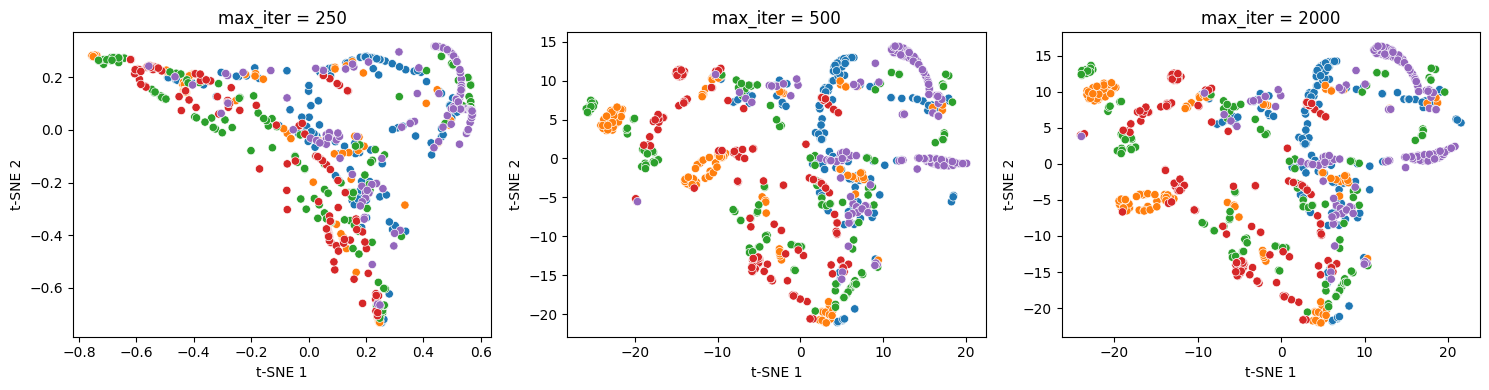

In [73]:
plot_tsne_param(
    param_name="max_iter",
    param_values=default_tsne_hyperparams['max_iter'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 4.0 CA Continuity 0.9912616267427787 CA Trustworthiness 0.9914810274883266
Value: 12.0 CA Continuity 0.9932304869478673 CA Trustworthiness 0.9912697926948709
Value: 24.0 CA Continuity 0.9926628206595186 CA Trustworthiness 0.9922591374144346


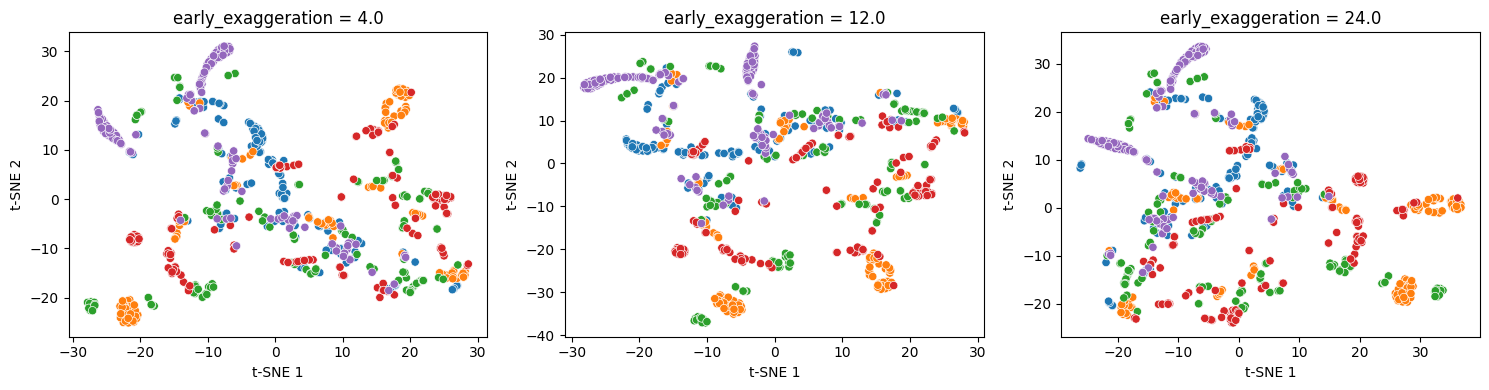

In [74]:
plot_tsne_param(
    param_name="early_exaggeration",
    param_values=default_tsne_hyperparams['early_exaggeration'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 10 CA Continuity 0.9931891616870065 CA Trustworthiness 0.9921046713580405
Value: 100 CA Continuity 0.993263912977401 CA Trustworthiness 0.9920718909419031
Value: 1000 CA Continuity 0.9926562972065145 CA Trustworthiness 0.9903141649390962


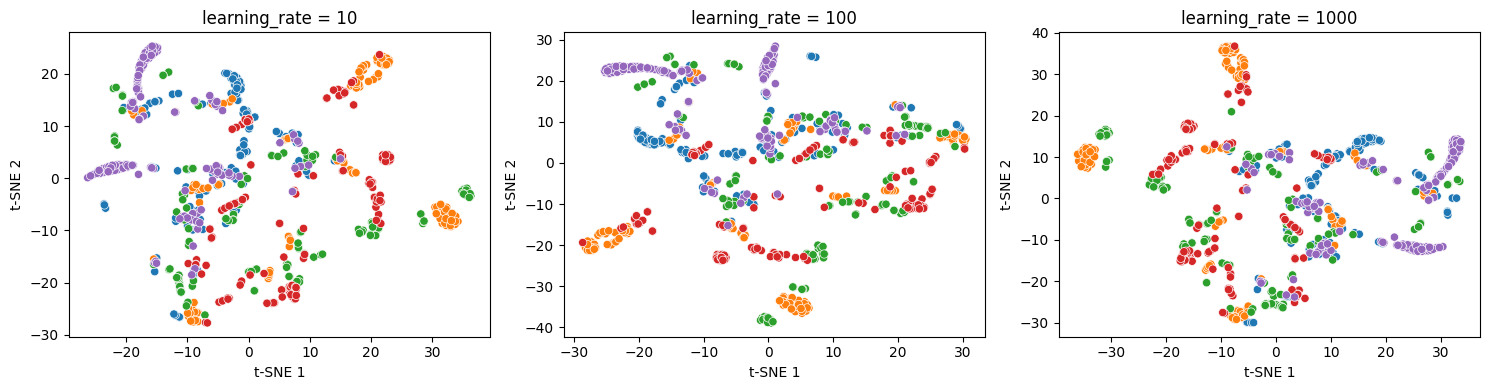

In [75]:
plot_tsne_param(
    param_name="learning_rate",
    param_values=default_tsne_hyperparams['learning_rate'],
    distance_matrix=dist_mat,
    labels=labels
)

In [25]:
sorted(results, key=lambda x: -1 * x['ca_continuity'])

[{'perplexity': 30,
  'n_iter': 500,
  'early_exaggeration': 24.0,
  'learning_rate': 0.25,
  'ca_trustworhiness': np.float64(0.9750570014254937),
  'ca_continuity': np.float64(0.9941069025864877),
  'embedding': array([[ 3.5827932 ,  1.1376339 ],
         [ 0.77500534,  2.0333185 ],
         [-0.6716491 , -1.6324599 ],
         ...,
         [-3.305091  ,  2.0520077 ],
         [ 1.2845775 ,  1.830971  ],
         [-2.4595497 ,  4.072922  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 50,
  'n_iter': 1000,
  'early_exaggeration': 12.0,
  'learning_rate': 0.25,
  'ca_trustworhiness': np.float64(0.9891122665331771),
  'ca_continuity': np.float64(0.994032896528827),
  'embedding': array([[ 9.217441  , -4.522689  ],
         [ 6.5526943 ,  1.6653394 ],
         [-8.139124  , -0.23555233],
         ...,
         [-5.4129477 ,  8.192281  ],
         [ 6.631241  ,  0.30920315],
         [-2.382821  , 11.174773  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 50,
  'n_iter': 500,
 

In [24]:
sorted(results, key=lambda x: -1 * x['ca_trustworhiness'])

[{'perplexity': 50,
  'n_iter': 1000,
  'early_exaggeration': 4.0,
  'learning_rate': 0.25,
  'ca_trustworhiness': np.float64(0.9909807479592412),
  'ca_continuity': np.float64(0.9907529425529639),
  'embedding': array([[ 9.403801 , -6.9124026],
         [ 9.497583 ,  1.8831664],
         [-4.773329 , -1.7749102],
         ...,
         [-5.895872 ,  8.860123 ],
         [ 9.725977 ,  0.7309053],
         [-3.0899804, 11.1982   ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 50,
  'n_iter': 1000,
  'early_exaggeration': 8.0,
  'learning_rate': 0.25,
  'ca_trustworhiness': np.float64(0.9908220426875438),
  'ca_continuity': np.float64(0.9934240866307199),
  'embedding': array([[ 9.8167715 , -4.4360275 ],
         [ 7.333178  ,  2.3457901 ],
         [-8.077     , -1.0209091 ],
         ...,
         [-6.4258494 ,  7.578929  ],
         [ 7.571268  ,  0.98502636],
         [-3.2589025 , 10.660756  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 50,
  'n_iter': 1000,
  'early_exa

(750,) (750,)
(750,) (750,)
(750,) (750,)
(750,) (750,)


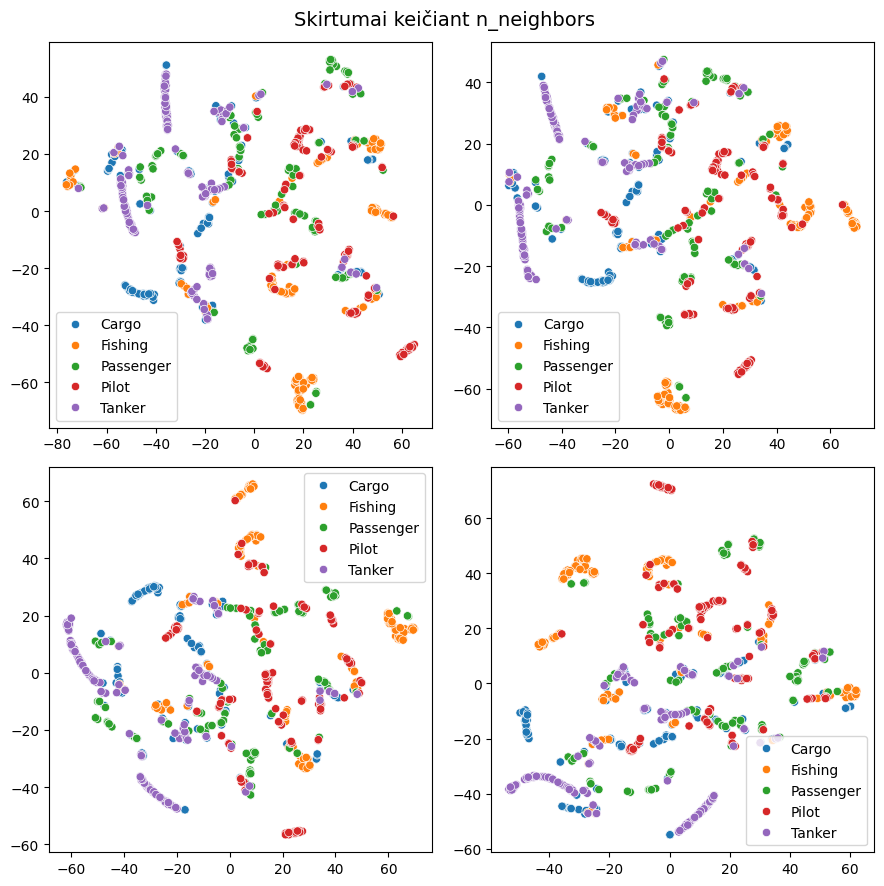

## UMAP tyrimas

In [36]:
def plot_umap(data, n_neighbors=20, min_dist=0.01, ax=None, var='n_neighbors'):
    embeddings = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric='precomputed', random_state=1).fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], s=25, alpha=0.8, hue=labels, palette='bright', ax=ax)

    ax.set_title(f"{var}={locals()[var]}")

/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/lukas/Dokumentai/studijos/ais-duomenu-vizualizavimas/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lukas/Dokumentai/studijos/ai

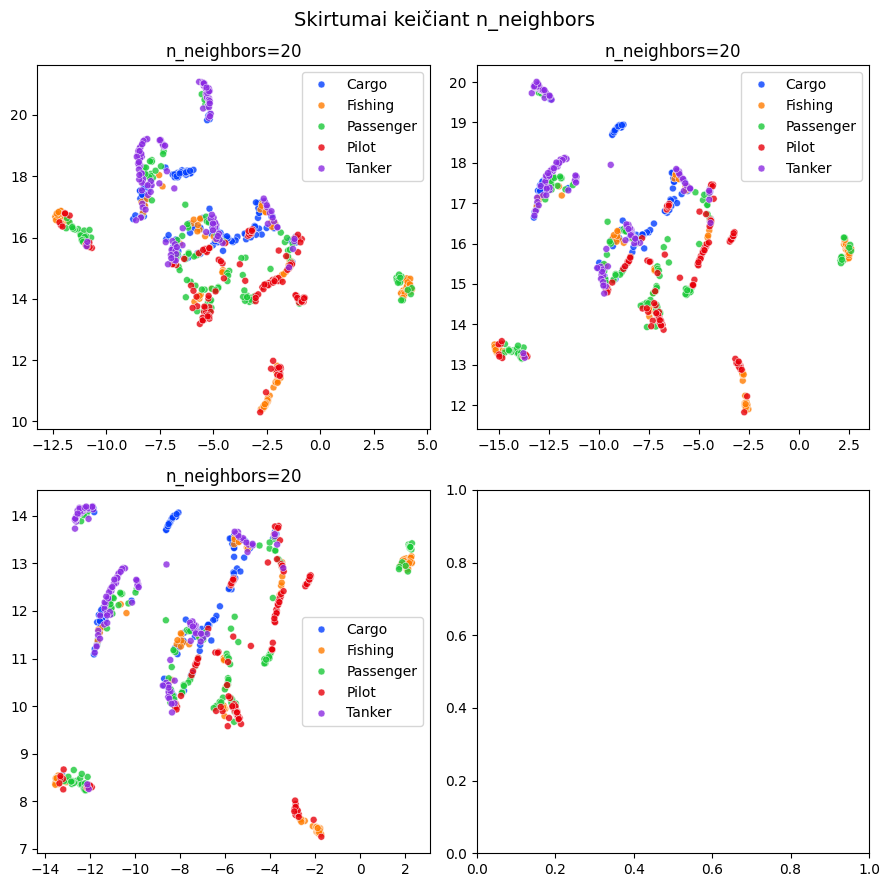

In [37]:
min_distances = [0.1, 0.001, 0.00001]
fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()
fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)

for i, n in enumerate(min_distances):
    plot_umap(data=dist_mat, min_dist=n, ax=axs[i])

plt.tight_layout()
plt.show()

In [ ]:
class_aware_trustworthiness_continuity.measure(
    
)

TypeError: measure() missing 3 required positional arguments: 'orig', 'emb', and 'label'